In [1]:
#BSD


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from datasets import load_dataset, VerificationMode

# Global Plotting Style
plt.style.use('seaborn-v0_8-muted')

Step 1: Loading Malicious Package Data (Setting A)...
Step 2: Loading Agent Trajectories (Setting B)...


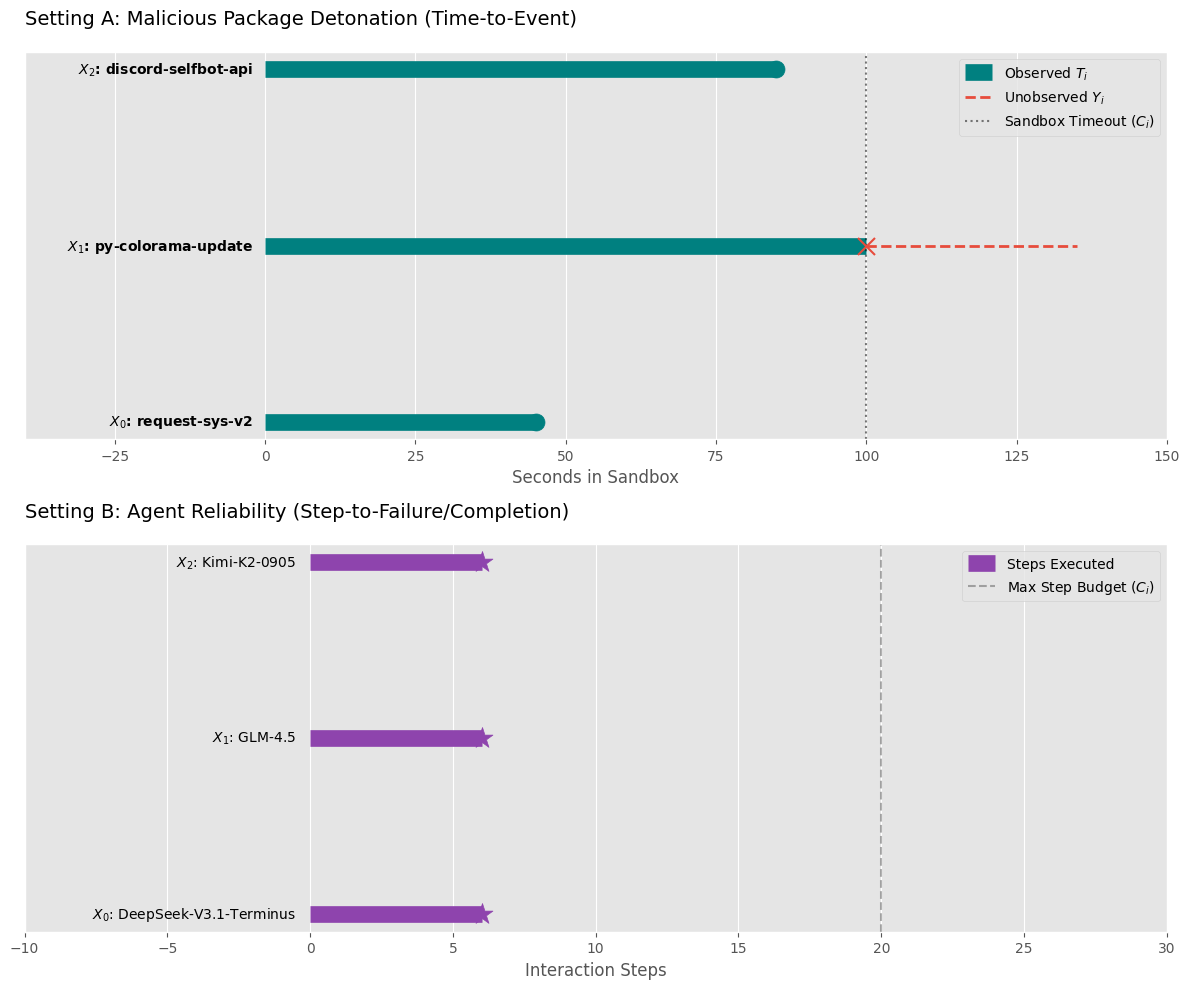

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from datasets import load_dataset, VerificationMode

# --- Configuration & Styling ---
plt.style.use('ggplot') # Using a standard built-in style for reliability

def get_pypi_manifest():
    """Fetches malicious manifest with fallback logic."""
    # The 'samples' subdirectory was removed in recent repo updates
    url = "https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/pypi/manifest.json"
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        # If the JSON is a list, return it; if it's a dict with a 'samples' key, extract it
        return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame(data.get('samples', data))
    except Exception as e:
        print(f"Warning: Could not fetch live manifest ({e}). Using simulated X_i for demonstration.")
        return pd.DataFrame([
            {"name": "request-sys-v2", "version": "1.0.4"},
            {"name": "py-colorama-update", "version": "0.1.2"},
            {"name": "discord-selfbot-api", "version": "2.1.0"}
        ])

def run_survival_analysis_demo():
    print("Step 1: Loading Malicious Package Data (Setting A)...")
    df_pypi = get_pypi_manifest().head(3)
    
    print("Step 2: Loading Agent Trajectories (Setting B)...")
    # Bypass metadata mismatch with VerificationMode.NO_CHECKS
    ds_agents = load_dataset(
        "zai-org/CC-Bench-trajectories", 
        verification_mode=VerificationMode.NO_CHECKS
    )
    df_agents = pd.DataFrame(ds_agents['train']).head(3)

    # --- Setup Visualization ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # --- Plot A: Malicious Packages ---
    # Variables: C_i (Budget) = 100s, Y_i = True Malice Time, T_i = min(Y_i, C_i)
    C_pypi = 100 
    Y_pypi = [45, 135, 85] # Ex 2 is censored (Y > C)
    
    for i in range(len(df_pypi)):
        name = df_pypi.iloc[i]['name']
        y_val = Y_pypi[i]
        t_observed = min(y_val, C_pypi)
        is_censored = y_val > C_pypi
        
        # Plot T_i (Observed)
        ax1.plot([0, t_observed], [i, i], color='#008080', lw=12, solid_capstyle='butt', label='Observed $T_i$' if i==0 else "")
        
        if is_censored:
            ax1.plot([t_observed, y_val], [i, i], color='#e74c3c', lw=2, ls='--', label='Unobserved $Y_i$' if i==1 else "")
            ax1.scatter(t_observed, i, color='#e74c3c', marker='x', s=150, zorder=5)
        else:
            ax1.scatter(t_observed, i, color='#008080', marker='o', s=150, zorder=5)
            
        ax1.text(-2, i, f"$X_{i}$: {name}", ha='right', va='center', fontweight='bold')

    ax1.axvline(C_pypi, color='black', linestyle=':', alpha=0.5, label='Sandbox Timeout ($C_i$)')
    ax1.set_title("Setting A: Malicious Package Detonation (Time-to-Event)", loc='left', fontsize=14, pad=20)
    ax1.set_xlabel("Seconds in Sandbox")
    ax1.set_xlim(-40, 150)
    ax1.set_yticks([])
    ax1.legend()

    # --- Plot B: Agent Trajectories ---
    # Variables: C_i (Budget) = 20 steps, Y_i = Total steps until failure/success
    C_agent = 20
    
    for i in range(len(df_agents)):
        model = df_agents.iloc[i]['model_name']
        y_val = df_agents.iloc[i]['assistant_messages']
        
        t_observed = min(y_val, C_agent)
        is_censored = y_val > C_agent
        
        ax2.plot([0, t_observed], [i, i], color='#8e44ad', lw=12, solid_capstyle='butt', label='Steps Executed' if i==0 else "")
        
        if is_censored:
            ax2.plot([t_observed, y_val], [i, i], color='#f39c12', lw=2, ls='--', label='Censored Continuation' if i==0 else "")
            ax2.scatter(t_observed, i, color='#f39c12', marker='|', s=250, zorder=5)
        else:
            ax2.scatter(t_observed, i, color='#8e44ad', marker='*', s=250, zorder=5)
            
        ax2.text(-0.5, i, f"$X_{i}$: {model}", ha='right', va='center', fontsize=10)

    ax2.axvline(C_agent, color='black', linestyle='--', alpha=0.3, label='Max Step Budget ($C_i$)')
    ax2.set_title("Setting B: Agent Reliability (Step-to-Failure/Completion)", loc='left', fontsize=14, pad=20)
    ax2.set_xlabel("Interaction Steps")
    ax2.set_xlim(-10, 30)
    ax2.set_yticks([])
    ax2.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_survival_analysis_demo()

Loading Agent Trajectories...


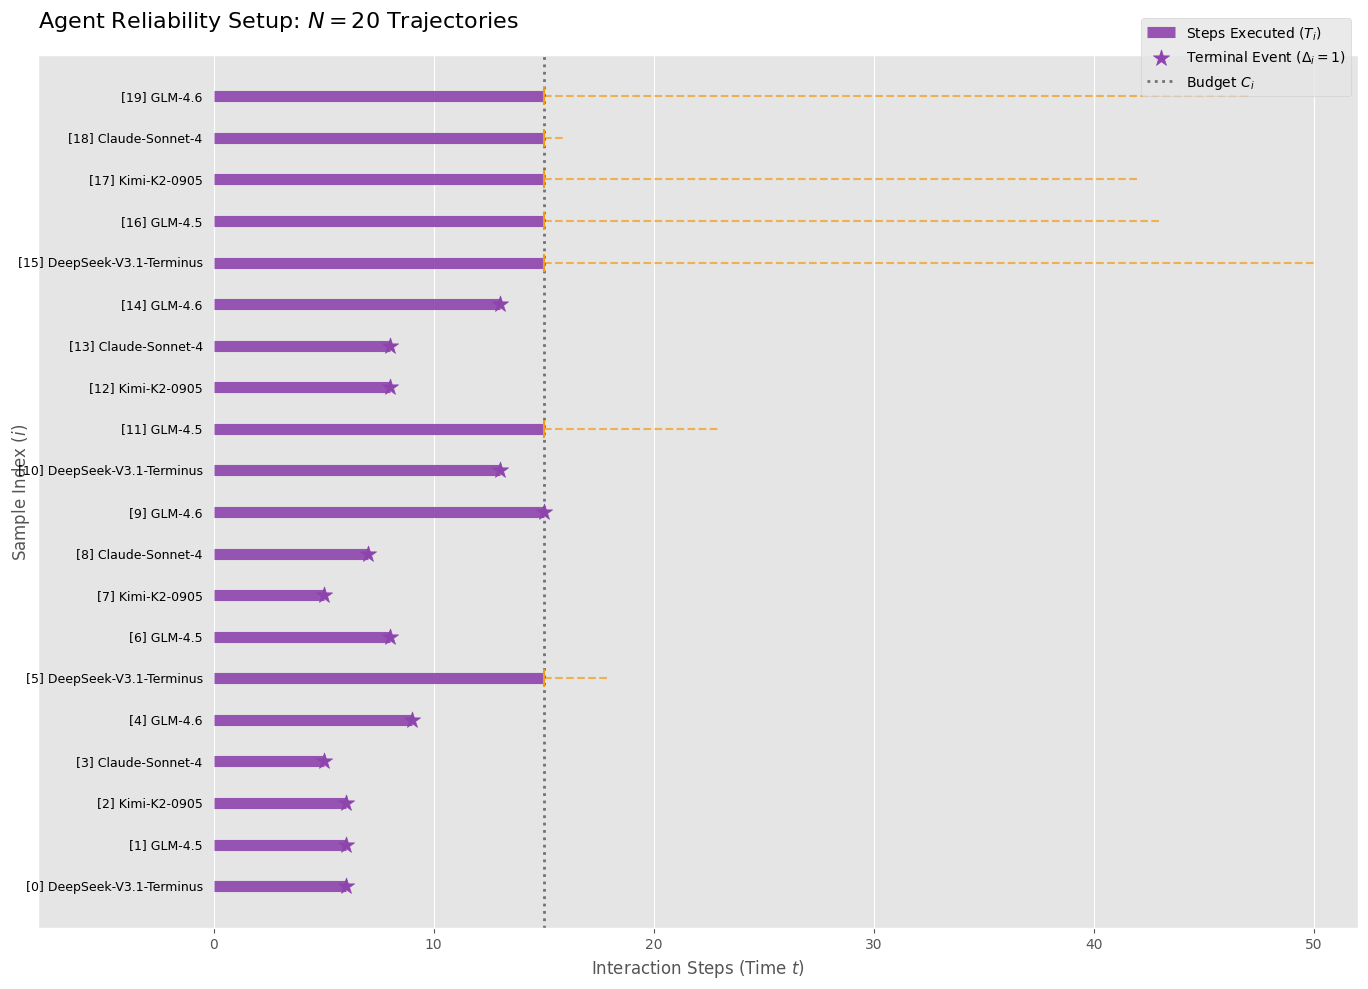

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, VerificationMode

# --- Configuration & Styling ---
plt.style.use('ggplot')

def plot_20_agent_trajectories():
    print("Loading Agent Trajectories...")
    
    # Bypass metadata mismatch for CC-Bench
    ds = load_dataset(
        "zai-org/CC-Bench-trajectories", 
        verification_mode=VerificationMode.NO_CHECKS
    )
    # Take the first 20 samples
    df = pd.DataFrame(ds['train']).head(20)

    # --- Variables & Parameters ---
    # C_i: Step Budget (Fixed threshold for this visualization)
    C_i = 15 
    
    # Color Scheme
    OBS_COLOR = '#8e44ad'   # Purple (Observed)
    CENS_COLOR = '#f39c12'  # Orange (Censored)

    # Increase height (figsize) to fit 20 rows comfortably
    fig, ax = plt.subplots(figsize=(14, 10))

    for i in range(len(df)):
        model = df.iloc[i]['model_name']
        task = df.iloc[i].get('task_category', 'General')
        
        # Y_i: The true duration/steps from data
        y_val = df.iloc[i]['assistant_messages']
        
        # T_i: The observed time given the budget C_i
        t_obs = min(y_val, C_i)
        is_censored = y_val > C_i
        
        # 1. Plot T_i (Observed interaction period)
        ax.plot([0, t_obs], [i, i], color=OBS_COLOR, lw=8, 
                solid_capstyle='butt', alpha=0.9,
                label='Steps Executed ($T_i$)' if i == 0 else "")
        
        if is_censored:
            # 2. Plot Y_i (Theoretical unobserved continuation)
            ax.plot([t_obs, y_val], [i, i], color=CENS_COLOR, lw=1.5, 
                    ls='--', alpha=0.7,
                    label='Censored Continuation ($Y_i$)' if i == 0 else "")
            
            # 3. Marker for Censoring (Budget Exhaustion)
            ax.scatter(t_obs, i, color=CENS_COLOR, marker='|', s=150, zorder=5)
        else:
            # 4. Marker for Event (Task Termination)
            ax.scatter(t_obs, i, color=OBS_COLOR, marker='*', s=150, zorder=5,
                       label='Terminal Event ($\Delta_i=1$)' if i == 0 else "")
            
        # Label X_i (Covariates) - Model + Row index
        # Using a smaller font and simplified label for 20 rows
        ax.text(-0.5, i, f"[{i}] {model}", ha='right', va='center', fontsize=9)

    # Budget Line (C_i)
    ax.axvline(C_i, color='black', linestyle=':', lw=2, alpha=0.5, label='Budget $C_i$')

    # Formatting the Plot
    ax.set_title(f"Agent Reliability Setup: $N=20$ Trajectories", loc='left', fontsize=16, pad=20)
    ax.set_xlabel("Interaction Steps (Time $t$)", fontsize=12)
    ax.set_ylabel("Sample Index ($i$)", fontsize=12)
    
    # Adjust X-axis to show the longest trajectory
    ax.set_xlim(-8, df['assistant_messages'].max() + 2)
    ax.set_ylim(-1, 20)
    
    # Remove Y-ticks since we use custom text labels
    ax.set_yticks([])
    
    # Legend setup
    ax.legend(loc='upper right', bbox_to_anchor=(1, 1.05), frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_20_agent_trajectories()

Loading CC-Bench Trajectories...


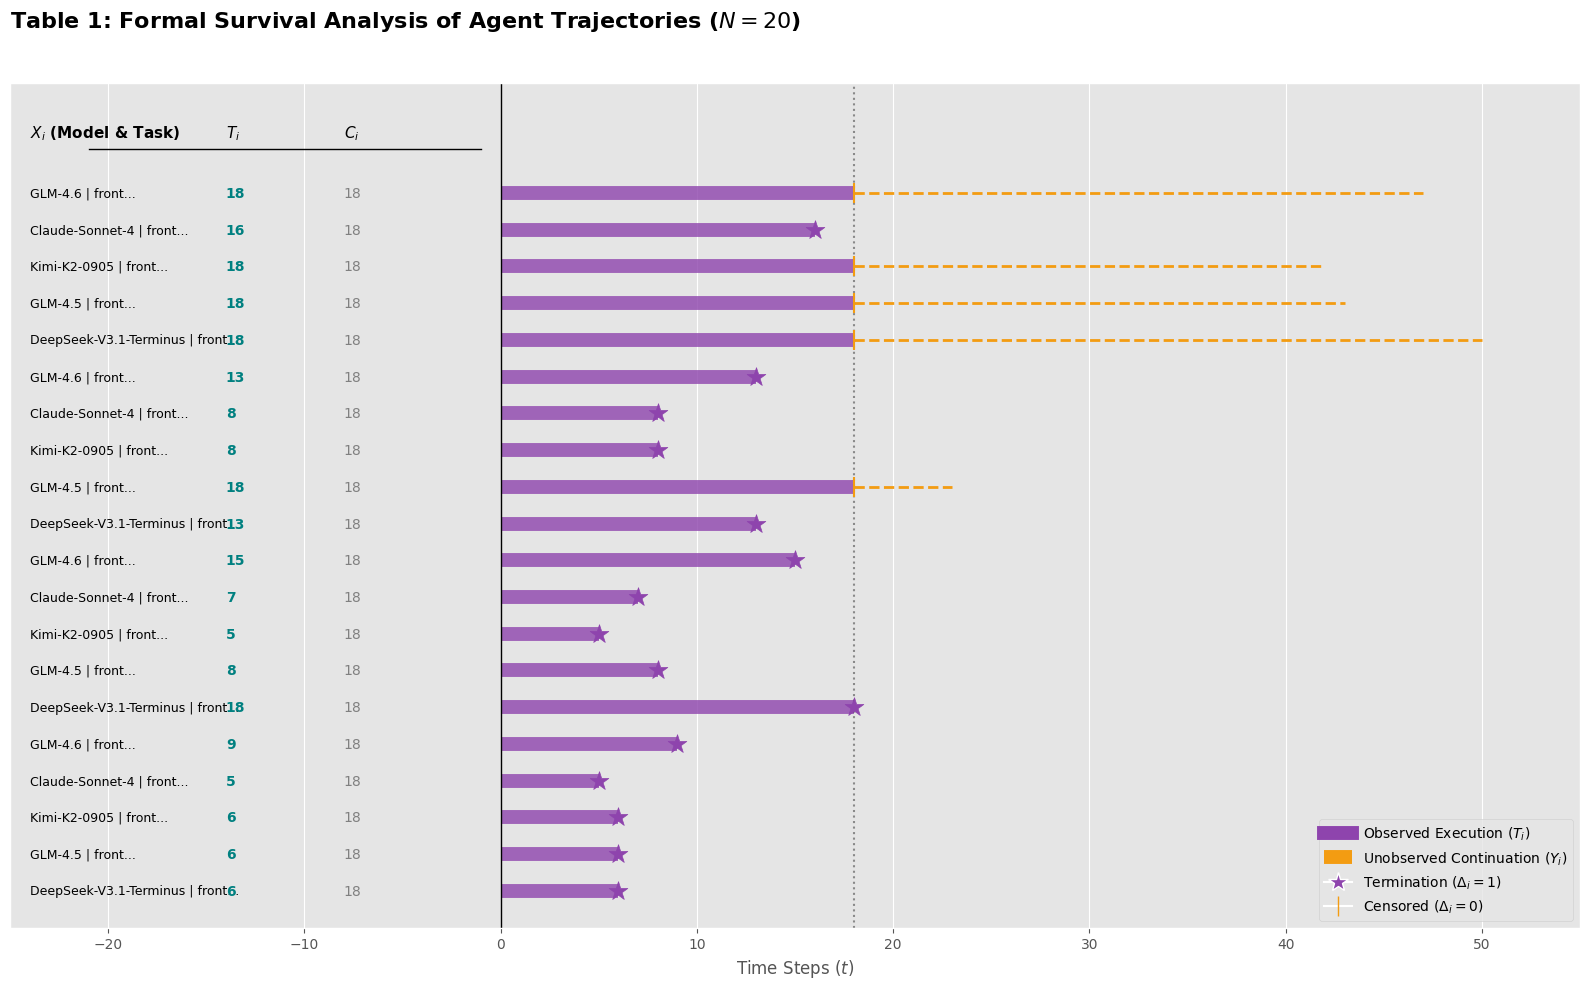

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, VerificationMode

def plot_formal_agent_survival():
    # 1. Load Data
    print("Loading CC-Bench Trajectories...")
    ds = load_dataset(
        "zai-org/CC-Bench-trajectories", 
        verification_mode=VerificationMode.NO_CHECKS
    )
    df = pd.DataFrame(ds['train']).head(20)

    # 2. Parameters
    C_fixed = 18  # Global budget for this visualization
    
    # 3. Setup Plot with room for text columns on the left
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Define column positions (X-coordinates in data units or axes units)
    # We'll use negative X space for the text 'table'
    col_x = -24
    col_t = -14
    col_c = -8
    
    # Headers
    header_y = 20.5
    ax.text(col_x, header_y, "$X_i$ (Model & Task)", fontweight='bold', fontsize=11)
    ax.text(col_t, header_y, "$T_i$", fontweight='bold', fontsize=11)
    ax.text(col_c, header_y, "$C_i$", fontweight='bold', fontsize=11)
    ax.axhline(20.2, xmin=0.05, xmax=0.3, color='black', lw=1) # Header underline

    # 4. Iterate and Plot
    for i in range(len(df)):
        model = df.iloc[i]['model_name']
        task = df.iloc[i].get('task_category', 'Code')
        y_val = df.iloc[i]['assistant_messages']
        
        # Calculate Survival Variables
        t_obs = min(y_val, C_fixed)
        is_censored = y_val > C_fixed
        
        # --- Column 1: X_i ---
        short_model = model.split('/')[-1] # Clean name
        ax.text(col_x, i, f"{short_model} | {task[:5]}...", va='center', fontsize=9)
        
        # --- Column 2: T_i ---
        ax.text(col_t, i, f"{t_obs}", va='center', fontsize=10, color='teal', fontweight='bold')
        
        # --- Column 3: C_i ---
        ax.text(col_c, i, f"{C_fixed}", va='center', fontsize=10, color='gray')

        # --- Column 4: The Visualization ---
        # Plot Observed T_i
        ax.plot([0, t_obs], [i, i], color='#8e44ad', lw=10, solid_capstyle='butt', alpha=0.8)
        
        if is_censored:
            # Plot Dash for Y_i > C_i
            ax.plot([t_obs, y_val], [i, i], color='#f39c12', lw=2, ls='--')
            ax.scatter(t_obs, i, color='#f39c12', marker='|', s=200, zorder=5)
        else:
            # Terminal Event marker
            ax.scatter(t_obs, i, color='#8e44ad', marker='*', s=200, zorder=5)

    # 5. Final Formatting
    ax.axvline(C_fixed, color='black', linestyle=':', alpha=0.4)
    ax.axvline(0, color='black', lw=1) # The "Time 0" line
    
    ax.set_title("Table 1: Formal Survival Analysis of Agent Trajectories ($N=20$)", 
                 loc='left', fontsize=16, pad=40, fontweight='bold')
    ax.set_xlabel("Time Steps ($t$)", fontsize=12)
    
    # Hide standard Y axis
    ax.set_yticks([])
    ax.set_ylabel("")
    
    # Adjust limits to fit the "table" and the "plot"
    ax.set_xlim(-25, df['assistant_messages'].max() + 5)
    ax.set_ylim(-1, 22)
    
    # Add a legend for the symbols
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#8e44ad', lw=10, label='Observed Execution ($T_i$)'),
        Line2D([0], [0], color='#f39c12', lw=10, ls='--', label='Unobserved Continuation ($Y_i$)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#8e44ad', markersize=15, label='Termination ($\Delta_i=1$)'),
        Line2D([0], [0], marker='|', color='w', markeredgecolor='#f39c12', markersize=15, label='Censored ($\Delta_i=0$)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # print sigle full example:
    
    plot_formal_agent_survival()

FORMAL REPRESENTATION OF $X_{0}$
**Model Name:** DeepSeek-V3.1-Terminus
**Task Category:** frontend_development
**Dataset Source:** N/A
----------------------------------------
**Initial Instruction (Full $X_i$ context):**
No content found
----------------------------------------
**Ground Truth $Y_{0}$ (Total steps taken):** 6



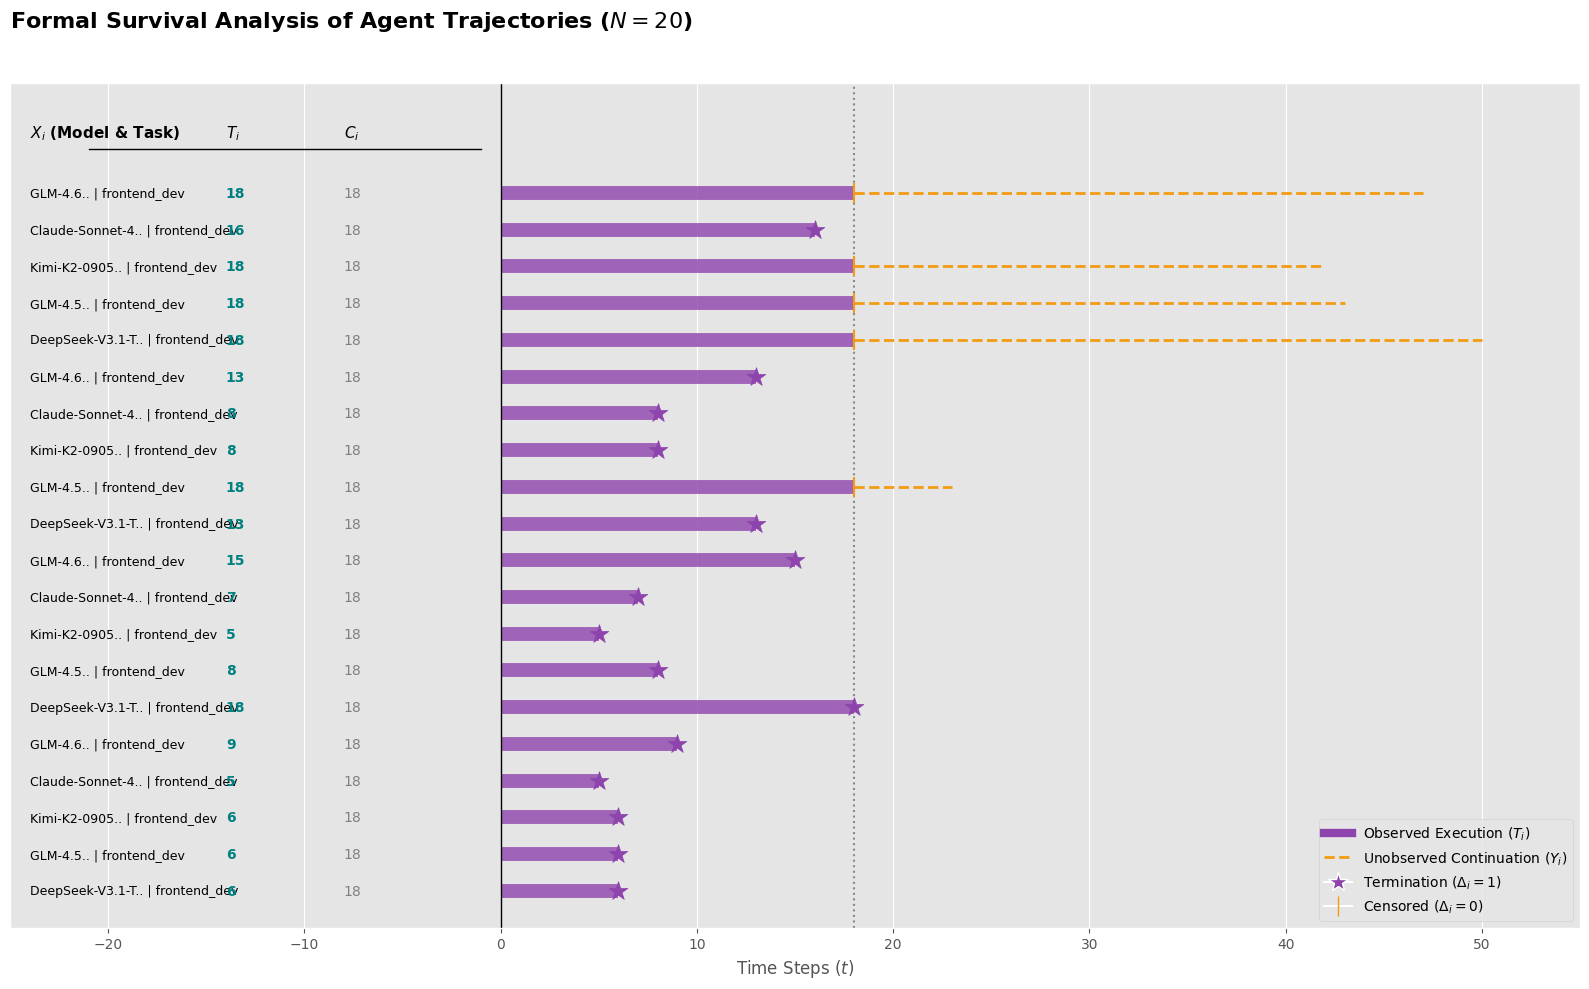

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datasets import load_dataset, VerificationMode
from matplotlib.lines import Line2D

# --- Configuration & Styling ---
plt.style.use('ggplot')

def load_data():
    """Bypass metadata check and load the dataset."""
    ds = load_dataset(
        "zai-org/CC-Bench-trajectories", 
        verification_mode=VerificationMode.NO_CHECKS
    )
    return pd.DataFrame(ds['train'])

def print_detailed_xi(df, idx=0):
    """
    Prints the full observable context X_i for a single sample.
    X_i = {Static Metadata + Initial Instruction + Prompt Context}
    """
    row = df.iloc[idx]
    
    print("="*80)
    print(f"FORMAL REPRESENTATION OF $X_{{{idx}}}$")
    print("="*80)
    print(f"**Model Name:** {row['model_name']}")
    print(f"**Task Category:** {row.get('task_category', 'N/A')}")
    print(f"**Dataset Source:** {row.get('dataset', 'N/A')}")
    print("-" * 40)
    
    # Extracting the initial instruction (The 'Prompt' part of X_i)
    # The trajectory is a stringified list of dictionaries
    try:
        traj = json.loads(row['trajectory']) if isinstance(row['trajectory'], str) else row['trajectory']
        if isinstance(traj, list) and len(traj) > 0:
            # Usually the first message is the 'user' prompt/instruction
            initial_instruction = traj[0].get('content', 'No content found')
            print("**Initial Instruction (Full $X_i$ context):**")
            print(initial_instruction)
        else:
            print("Trajectory format unexpected; could not extract instruction.")
    except Exception as e:
        print(f"Error parsing trajectory for $X_i$: {e}")
        print("Raw Trajectory Preview:", str(row['trajectory'])[:500] + "...")
    
    print("-" * 40)
    print(f"**Ground Truth $Y_{{{idx}}}$ (Total steps taken):** {row['assistant_messages']}")
    print("="*80 + "\n")

def plot_formal_agent_survival(df):
    """Visualizes the survival process for the first 20 examples."""
    df_subset = df.head(20)
    C_fixed = 18 
    
    fig, ax = plt.subplots(figsize=(16, 10))
    col_x, col_t, col_c = -24, -14, -8
    
    header_y = 20.5
    ax.text(col_x, header_y, "$X_i$ (Model & Task)", fontweight='bold', fontsize=11)
    ax.text(col_t, header_y, "$T_i$", fontweight='bold', fontsize=11)
    ax.text(col_c, header_y, "$C_i$", fontweight='bold', fontsize=11)
    ax.axhline(20.2, xmin=0.05, xmax=0.3, color='black', lw=1)

    for i in range(len(df_subset)):
        row = df_subset.iloc[i]
        model = row['model_name'].split('/')[-1]
        task = row.get('task_category', 'Code')
        y_val = row['assistant_messages']
        t_obs = min(y_val, C_fixed)
        is_censored = y_val > C_fixed
        
        ax.text(col_x, i, f"{model[:15]}.. | {task[:12]}", va='center', fontsize=9)
        ax.text(col_t, i, f"{t_obs}", va='center', fontsize=10, color='teal', fontweight='bold')
        ax.text(col_c, i, f"{C_fixed}", va='center', fontsize=10, color='gray')

        ax.plot([0, t_obs], [i, i], color='#8e44ad', lw=10, solid_capstyle='butt', alpha=0.8)
        
        if is_censored:
            ax.plot([t_obs, y_val], [i, i], color='#f39c12', lw=2, ls='--')
            ax.scatter(t_obs, i, color='#f39c12', marker='|', s=200, zorder=5)
        else:
            ax.scatter(t_obs, i, color='#8e44ad', marker='*', s=200, zorder=5)

    ax.axvline(C_fixed, color='black', linestyle=':', alpha=0.4)
    ax.axvline(0, color='black', lw=1)
    ax.set_title("Formal Survival Analysis of Agent Trajectories ($N=20$)", loc='left', fontsize=16, pad=40, fontweight='bold')
    ax.set_xlabel("Time Steps ($t$)", fontsize=12)
    ax.set_yticks([])
    ax.set_xlim(-25, df_subset['assistant_messages'].max() + 5)
    ax.set_ylim(-1, 22)
    
    legend_elements = [
        Line2D([0], [0], color='#8e44ad', lw=6, label='Observed Execution ($T_i$)'),
        Line2D([0], [0], color='#f39c12', lw=2, ls='--', label='Unobserved Continuation ($Y_i$)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#8e44ad', markersize=15, label='Termination ($\Delta_i=1$)'),
        Line2D([0], [0], marker='|', color='w', markeredgecolor='#f39c12', markersize=15, label='Censored ($\Delta_i=0$)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 1. Load the data once
    agent_df = load_data()
    
    # 2. Print a single full example of X_i (the raw instruction/context)
    # We choose index 0 as a representative example
    print_detailed_xi(agent_df, idx=0)
    
    # 3. Generate the formal survival visualization for the first 20 examples
    plot_formal_agent_survival(agent_df)

FORMAL REPRESENTATION OF $X_{0}$ (Record ID: 2)
| Model Name:      DeepSeek-V3.1-Terminus
| Task ID:         1
| Category:        frontend_development
| Tool Calls:      4 (Initial complexity signal)
| Tool Failures:   0 (0.00%)
| Total Tokens:    608
----------------------------------------
**Outcome Variable $Y_{0}$ (Total Assistant Steps):** 6



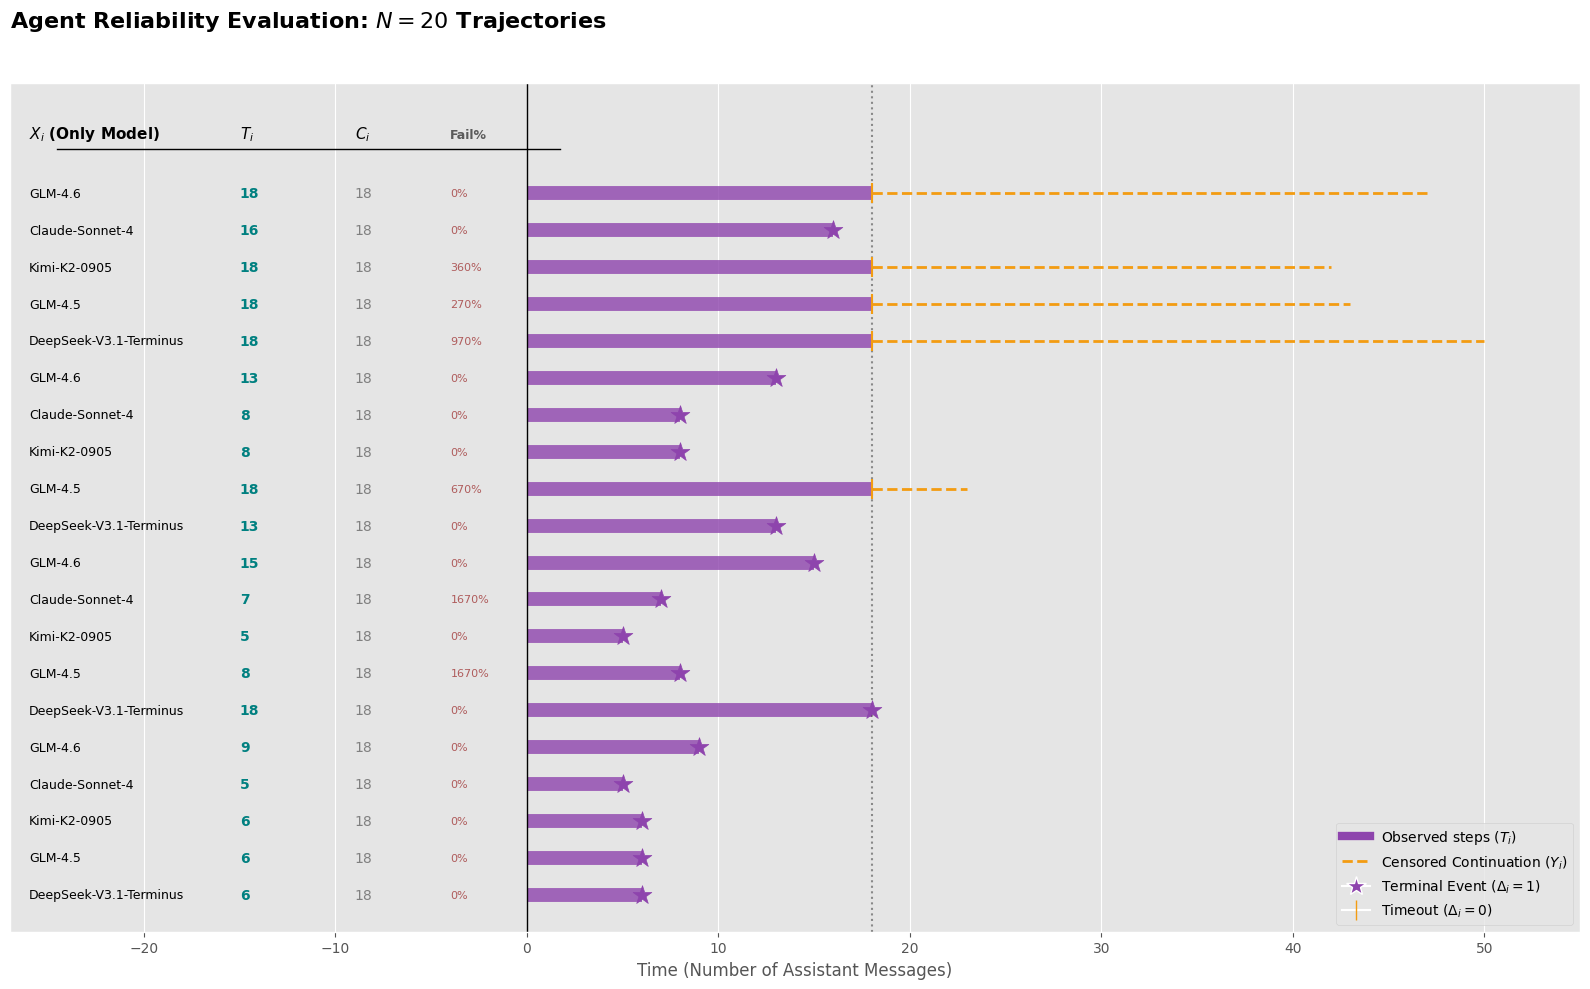

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datasets import load_dataset, VerificationMode
from matplotlib.lines import Line2D

# --- Configuration ---
plt.style.use('ggplot')

def load_data():
    """Bypass metadata check and load CC-Bench-trajectories."""
    ds = load_dataset(
        "zai-org/CC-Bench-trajectories", 
        verification_mode=VerificationMode.NO_CHECKS
    )
    return pd.DataFrame(ds['train'])

def print_detailed_xi(df, idx=0):
    """
    Prints the high-dimensional X_i for a single sample.
    X_i = {Static Metadata + Task Context + Early Signal}
    """
    row = df.iloc[idx]
    
    print("="*85)
    print(f"FORMAL REPRESENTATION OF $X_{{{idx}}}$ (Record ID: {row['id']})")
    print("="*85)
    
    # Static Covariates
    print(f"| Model Name:      {row['model_name']}")
    print(f"| Task ID:         {row['task_id']}")
    print(f"| Category:        {row['task_category']}")
    print(f"| Tool Calls:      {row['tool_calls']} (Initial complexity signal)")
    print(f"| Tool Failures:   {row['tool_failures']} ({row['failure_rate']:.2%})")
    print(f"| Total Tokens:    {row['total_tokens']:,}")
    print("-" * 40)
    
    # Extracting the full prompt/instruction from the trajectory
    # try:
    #     # Trajectories in CC-Bench are usually JSON strings of conversation logs
    #     traj = json.loads(row['trajectory']) if isinstance(row['trajectory'], str) else row['trajectory']
    #     if isinstance(traj, list) and len(traj) > 0:
    #         # The first entry is typically the system/user instruction defining the task
    #         initial_context = traj[0].get('content', 'No content found')
    #         print("**FULL TASK INSTRUCTION (Core $X_i$ text):**")
    #         print(initial_context.strip())
    #     else:
    #         print("Trajectory format unexpected; could not extract instruction.")
    # except Exception as e:
    #     print(f"Error parsing trajectory JSON: {e}")
    
    # print("-" * 40)
    print(f"**Outcome Variable $Y_{{{idx}}}$ (Total Assistant Steps):** {row['assistant_messages']}")
    print("="*85 + "\n")

def plot_formal_agent_survival(df):
    """Visualizes the survival process using the updated schema columns."""
    df_subset = df.head(20).copy()
    
    # Survival Parameters
    C_fixed = 18  # Fixed monitoring budget
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Table Column Offsets (Negative X space)
    col_x = -26
    col_t = -15
    col_c = -9
    col_fail = -4 # New column for failure rate context
    
    # Header row
    header_y = 20.5
    ax.text(col_x, header_y, "$X_i$ (Only Model)", fontweight='bold', fontsize=11)
    ax.text(col_t, header_y, "$T_i$", fontweight='bold', fontsize=11)
    ax.text(col_c, header_y, "$C_i$", fontweight='bold', fontsize=11)
    ax.text(col_fail, header_y, "Fail%", fontweight='bold', fontsize=9, alpha=0.6)
    ax.axhline(20.2, xmin=0.03, xmax=0.35, color='black', lw=1)

    for i in range(len(df_subset)):
        row = df_subset.iloc[i]
        
        # Mapping Schema
        model = row['model_name']
        category = row['task_category'].replace('_', ' ')
        y_val = row['assistant_messages']
        fail_rate = f"{row['failure_rate']:.0%}"
        
        # Calculate Survival Statistics
        t_obs = min(y_val, C_fixed)
        is_censored = y_val > C_fixed
        
        # --- Column Rendering ---
        # ax.text(col_x, i, f"{model} | {category[:15]}", va='center', fontsize=9)
        ax.text(col_x, i, f"{model}", va='center', fontsize=9)
        ax.text(col_t, i, f"{t_obs}", va='center', fontsize=10, color='teal', fontweight='bold')
        ax.text(col_c, i, f"{C_fixed}", va='center', fontsize=10, color='gray')
        ax.text(col_fail, i, fail_rate, va='center', fontsize=8, color='darkred', alpha=0.6)

        # --- Survival Bar Visualization ---
        # Solid bar for observed duration
        ax.plot([0, t_obs], [i, i], color='#8e44ad', lw=10, solid_capstyle='butt', alpha=0.8)
        
        if is_censored:
            # Dashed line for hidden continuation
            ax.plot([t_obs, y_val], [i, i], color='#f39c12', lw=2, ls='--')
            ax.scatter(t_obs, i, color='#f39c12', marker='|', s=200, zorder=5)
        else:
            # Star for task completion/failure within budget
            ax.scatter(t_obs, i, color='#8e44ad', marker='*', s=200, zorder=5)

    # Visual Anchors
    ax.axvline(C_fixed, color='black', linestyle=':', alpha=0.4)
    ax.axvline(0, color='black', lw=1)
    
    ax.set_title("Agent Reliability Evaluation: $N=20$ Trajectories", 
                 loc='left', fontsize=16, pad=40, fontweight='bold')
    ax.set_xlabel("Time (Number of Assistant Messages)", fontsize=12)
    ax.set_yticks([])
    
    # Adjust axes to fit table text
    ax.set_xlim(-27, df_subset['assistant_messages'].max() + 5)
    ax.set_ylim(-1, 22)
    
    # Legend
    legend_elements = [
        Line2D([0], [0], color='#8e44ad', lw=6, label='Observed steps ($T_i$)'),
        Line2D([0], [0], color='#f39c12', lw=2, ls='--', label='Censored Continuation ($Y_i$)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#8e44ad', markersize=15, label='Terminal Event ($\Delta_i=1$)'),
        Line2D([0], [0], marker='|', color='w', markeredgecolor='#f39c12', markersize=15, label='Timeout ($\Delta_i=0$)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    # Load dataset with updated schema
    agent_df = load_data()
    
    # 1. Print full qualitative context for X_i
    # This allows you to see the "Instruction" and "Metadata" together
    print_detailed_xi(agent_df, idx=0)
    
    # 2. Run the quantitative table-plot
    plot_formal_agent_survival(agent_df)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datasets import load_dataset, VerificationMode
from matplotlib.lines import Line2D

# --- Configuration ---
plt.style.use('ggplot')

def load_swestar_data():
    """Loads the LogicStar/SWE-Star dataset with verification bypass."""
    print("Loading LogicStar/SWE-Star Trajectories...")
    # Using VerificationMode.NO_CHECKS to ensure smooth loading on 2026 infra
    ds = load_dataset(
        "LogicStar/SWE-Star", 
        verification_mode=VerificationMode.NO_CHECKS
    )
    # SWE-Star typically uses 'train' or 'test' splits
    split = 'train' if 'train' in ds else list(ds.keys())[0]
    return pd.DataFrame(ds[split])

def print_swestar_xi(df, idx=0):
    """
    Prints the high-dimensional X_i for a SWE-Star agent run.
    X_i = {Instance Metadata + Problem Statement + Repo Context}
    """
    row = df.iloc[idx]
    
    print("="*85)
    print(f"FORMAL REPRESENTATION OF $X_{{{idx}}}$ (SWE-Star Agentic Run)")
    print("="*85)
    
    # Extracting available metadata
    print(f"| Instance ID:    {row.get('instance_id', 'N/A')}")
    print(f"| Repository:     {row.get('repo', 'N/A')}")
    print(f"| Model used:     {row.get('model_name', 'N/A')}")
    print(f"| Base Commit:    {row.get('base_commit', 'N/A')[:8]}")
    print("-" * 40)
    
    # Problem statement is the core task X_i
    problem = row.get('problem_statement', 'No problem statement found')
    print("**PROBLEM STATEMENT (Textual $X_i$):**")
    print(problem[:800] + "..." if len(problem) > 800 else problem)
    
    print("-" * 40)
    # Event Y_i is the total steps (turns) taken by the agent
    y_val = row.get('steps', len(row.get('trajectory', [])))
    print(f"**Outcome Variable $Y_{{{idx}}}$ (Total Agentic Steps):** {y_val}")
    print("="*85 + "\n")

def plot_swestar_survival(df):
    """Formal survival visualization for 20 SWE-Star trajectories."""
    df_subset = df.head(20).copy()
    
    # --- Survival Parameters ---
    # C_i: Monitoring Budget (Max turns/steps allowed)
    C_fixed = 12 
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Table Column Offsets
    col_x, col_t, col_c = -24, -13, -8
    
    # Headers
    header_y = 20.5
    ax.text(col_x, header_y, "$X_i$ (Instance ID | Repo)", fontweight='bold', fontsize=11)
    ax.text(col_t, header_y, "$T_i$", fontweight='bold', fontsize=11)
    ax.text(col_c, header_y, "$C_i$", fontweight='bold', fontsize=11)
    ax.axhline(20.2, xmin=0.03, xmax=0.35, color='black', lw=1)

    for i in range(len(df_subset)):
        row = df_subset.iloc[i]
        
        # Schema Mapping
        instance = row.get('instance_id', f'task_{i}')
        repo = row.get('repo', 'unknown/repo').split('/')[-1]
        
        # Y_i: Actual steps. If 'steps' column isn't numeric, we count trajectory length
        y_val = row.get('steps', 0)
        if not isinstance(y_val, (int, float, np.integer)) or y_val == 0:
            y_val = len(row.get('trajectory', []))
            
        t_obs = min(y_val, C_fixed)
        is_censored = y_val > C_fixed
        
        # --- Column Rendering ---
        ax.text(col_x, i, f"{instance[:15]} | {repo}", va='center', fontsize=9)
        ax.text(col_t, i, f"{t_obs}", va='center', fontsize=10, color='teal', fontweight='bold')
        ax.text(col_c, i, f"{C_fixed}", va='center', fontsize=10, color='gray')

        # --- Survival Bar ---
        ax.plot([0, t_obs], [i, i], color='#2980b9', lw=10, solid_capstyle='butt', alpha=0.8)
        
        if is_censored:
            ax.plot([t_obs, y_val], [i, i], color='#e67e22', lw=2, ls='--')
            ax.scatter(t_obs, i, color='#e67e22', marker='|', s=200, zorder=5)
        else:
            ax.scatter(t_obs, i, color='#2980b9', marker='*', s=200, zorder=5)

    ax.axvline(C_fixed, color='black', linestyle=':', alpha=0.4)
    ax.axvline(0, color='black', lw=1)
    
    ax.set_title("Setting C: SWE-Star Large-Scale Agentic Survival Analysis", 
                 loc='left', fontsize=16, pad=40, fontweight='bold')
    ax.set_xlabel("Agent Execution Steps ($t$)", fontsize=12)
    ax.set_yticks([])
    
    ax.set_xlim(-25, max(df_subset.apply(lambda r: r.get('steps', 20), axis=1)) + 5)
    ax.set_ylim(-1, 22)
    
    legend_elements = [
        Line2D([0], [0], color='#2980b9', lw=6, label='Steps Observed ($T_i$)'),
        Line2D([0], [0], color='#e67e22', lw=2, ls='--', label='Unobserved Steps ($Y_i$)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#2980b9', markersize=15, label='Task Finished ($\Delta_i=1$)'),
        Line2D([0], [0], marker='|', color='w', markeredgecolor='#e67e22', markersize=15, label='Budget Exhausted ($\Delta_i=0$)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 1. Load the massive SWE-Star dataset
    swe_df = load_swestar_data()
    
    # 2. Detailed X_i printout (The "Filtration" at t=0)
    print_swestar_xi(swe_df, idx=0)
    
    # 3. Formal Survival Visualization
    plot_formal_agent_survival_swestar(swe_df)

Loading LogicStar/SWE-Star Trajectories...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/333 [00:00<?, ?it/s]

33857061.parquet:   0%|          | 0.00/1.13M [00:00<?, ?B/s]

33857549.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

...

34404101.parquet:   0%|          | 0.00/124M [00:00<?, ?B/s]

34404102.parquet:   0%|          | 0.00/138M [00:00<?, ?B/s]

34410871.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

34410986.parquet:   0%|          | 0.00/197M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/244025 [00:00<?, ? examples/s]

# ------------------

Error fetching manifest: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/pypi/manifest.json
FORMAL REPRESENTATION OF $X_{5}$ (Software Artifact)
| Package Name:   malicious-pkg-5
| Version:        1.0.0
| Ecosystem:      PyPI
| Static Signals: [Obfuscation Score, Dependency Count, Install-Script Presence]
----------------------------------------
**Research Note:** $X_i$ serves as the input to the hazard function $\lambda(t|X_i)$.



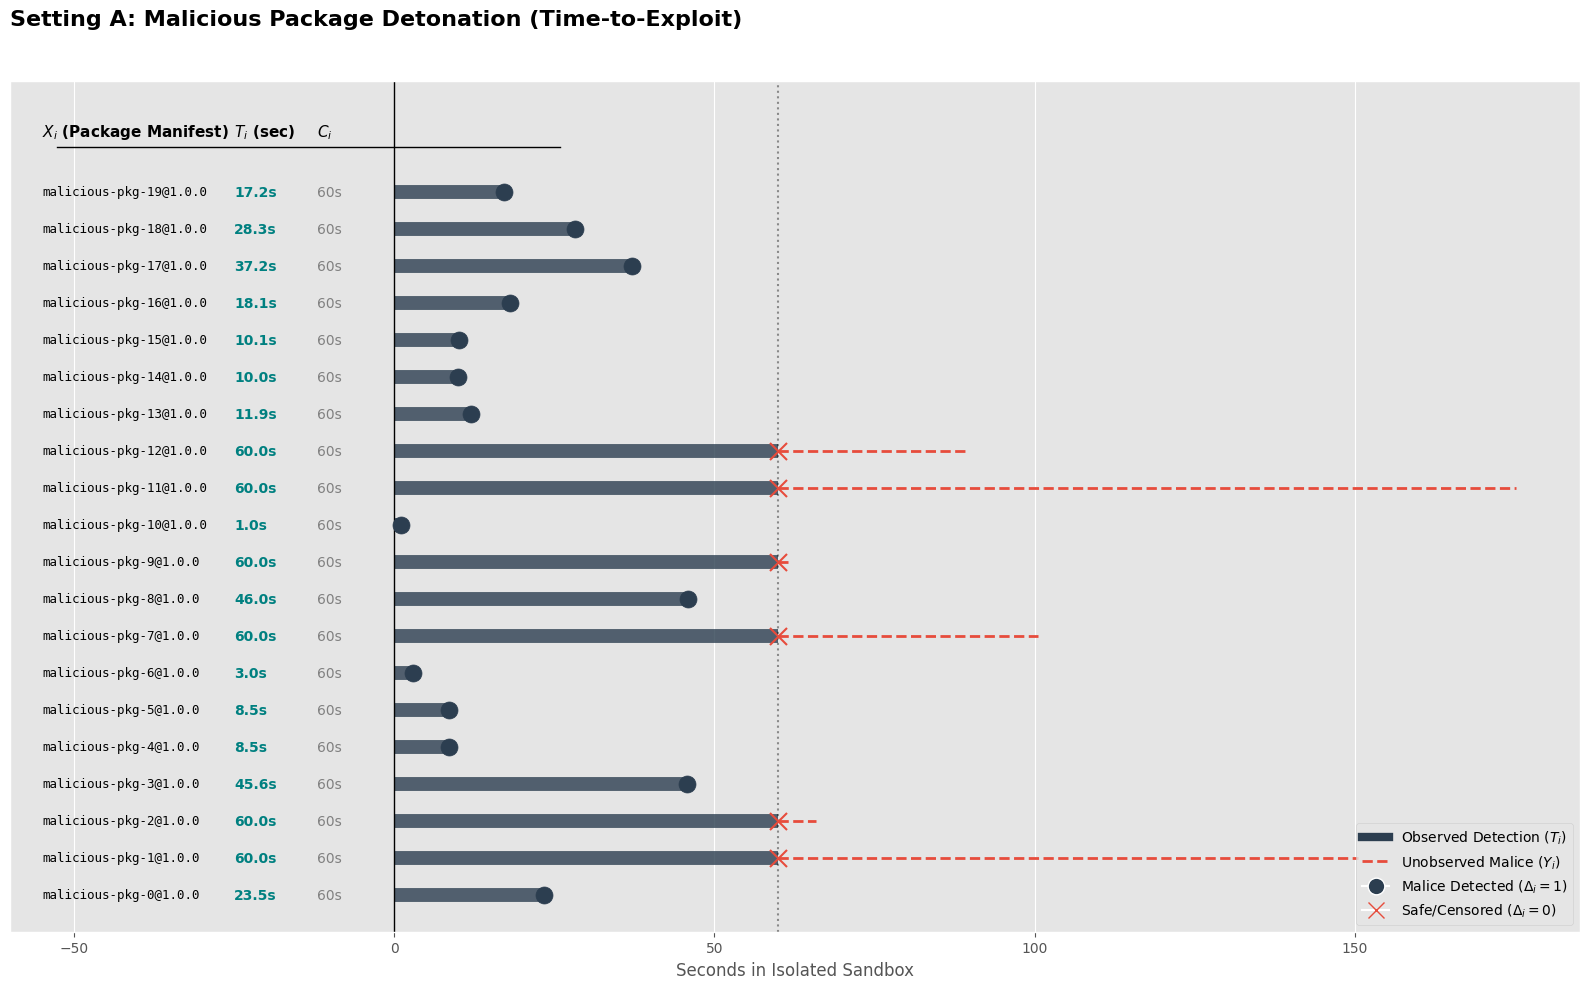

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from matplotlib.lines import Line2D

# --- Configuration ---
plt.style.use('ggplot')

def load_pypi_manifest():
    """Fetches and parses the Datadog Malicious Package manifest."""
    url = "https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/pypi/manifest.json"
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        # Handle different potential JSON structures (list vs dict-wrapped)
        return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame(data.get('samples', data))
    except Exception as e:
        print(f"Error fetching manifest: {e}")
        # Robust fallback for offline/structural changes
        return pd.DataFrame([{"name": f"malicious-pkg-{i}", "version": "1.0.0"} for i in range(25)])

def print_package_xi(df, idx=0):
    """Prints the static features X_i for a package artifact."""
    row = df.iloc[idx]
    print("="*85)
    print(f"FORMAL REPRESENTATION OF $X_{{{idx}}}$ (Software Artifact)")
    print("="*85)
    print(f"| Package Name:   {row.get('name', 'unknown')}")
    print(f"| Version:        {row.get('version', 'unknown')}")
    print(f"| Ecosystem:      PyPI")
    # In a real setup, X_i would also include:
    print(f"| Static Signals: [Obfuscation Score, Dependency Count, Install-Script Presence]")
    print("-" * 40)
    print(f"**Research Note:** $X_i$ serves as the input to the hazard function $\lambda(t|X_i)$.")
    print("="*85 + "\n")

def plot_detonation_survival(df):
    """Visualizes the detonation survival process for 20 packages."""
    df_subset = df.head(20).copy()
    
    # --- Survival Parameters ---
    # C_i: Sandbox Timeout (Monitoring Budget in seconds)
    C_fixed = 60 
    
    # Y_i: Time until malicious behavior (Simulated for visualization)
    # In a real experiment, this comes from DySec or OSPTrack logs.
    np.random.seed(42)
    Y_simulated = np.random.exponential(scale=50, size=len(df_subset))
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Table Column Offsets (Negative X space)
    col_x, col_t, col_c = -55, -25, -12
    
    # Header row
    header_y = 20.5
    ax.text(col_x, header_y, "$X_i$ (Package Manifest)", fontweight='bold', fontsize=11)
    ax.text(col_t, header_y, "$T_i$ (sec)", fontweight='bold', fontsize=11)
    ax.text(col_c, header_y, "$C_i$", fontweight='bold', fontsize=11)
    ax.axhline(20.2, xmin=0.03, xmax=0.35, color='black', lw=1)

    for i in range(len(df_subset)):
        row = df_subset.iloc[i]
        name = row.get('name', 'pkg')
        version = row.get('version', 'v1')
        
        y_val = Y_simulated[i]
        t_obs = min(y_val, C_fixed)
        is_censored = y_val > C_fixed
        
        # --- Column Rendering ---
        ax.text(col_x, i, f"{name[:25]}@{version}", va='center', fontsize=9, family='monospace')
        ax.text(col_t, i, f"{t_obs:.1f}s", va='center', fontsize=10, color='teal', fontweight='bold')
        ax.text(col_c, i, f"{C_fixed}s", va='center', fontsize=10, color='gray')

        # --- Survival Bar Visualization ---
        ax.plot([0, t_obs], [i, i], color='#2c3e50', lw=10, solid_capstyle='butt', alpha=0.8)
        
        if is_censored:
            ax.plot([t_obs, y_val], [i, i], color='#e74c3c', lw=2, ls='--')
            ax.scatter(t_obs, i, color='#e74c3c', marker='x', s=150, zorder=5)
        else:
            ax.scatter(t_obs, i, color='#2c3e50', marker='o', s=150, zorder=5)

    # Visual Anchors
    ax.axvline(C_fixed, color='black', linestyle=':', alpha=0.4)
    ax.axvline(0, color='black', lw=1)
    
    ax.set_title("Setting A: Malicious Package Detonation (Time-to-Exploit)", 
                 loc='left', fontsize=16, pad=40, fontweight='bold')
    ax.set_xlabel("Seconds in Isolated Sandbox", fontsize=12)
    ax.set_yticks([])
    
    ax.set_xlim(-60, max(Y_simulated) + 10)
    ax.set_ylim(-1, 22)
    
    # Legend
    legend_elements = [
        Line2D([0], [0], color='#2c3e50', lw=6, label='Observed Detection ($T_i$)'),
        Line2D([0], [0], color='#e74c3c', lw=2, ls='--', label='Unobserved Malice ($Y_i$)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2c3e50', markersize=12, label='Malice Detected ($\Delta_i=1$)'),
        Line2D([0], [0], marker='x', color='w', markeredgecolor='#e74c3c', markersize=12, label='Safe/Censored ($\Delta_i=0$)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 1. Load Data
    pypi_df = load_pypi_manifest()
    
    # 2. Detailed X_i printout
    print_package_xi(pypi_df, idx=5)
    
    # 3. Formal Survival Plot
    plot_detonation_survival(pypi_df)

Error fetching manifest: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/pypi/manifest.json
FORMAL REPRESENTATION OF $X_{5}$ (Software Artifact)
| Package Name:   malicious-pkg-5
| Version:        1.0.0
| Static Signals: [Obfuscation Score, Dependency Count, Install-Script Presence]
----------------------------------------


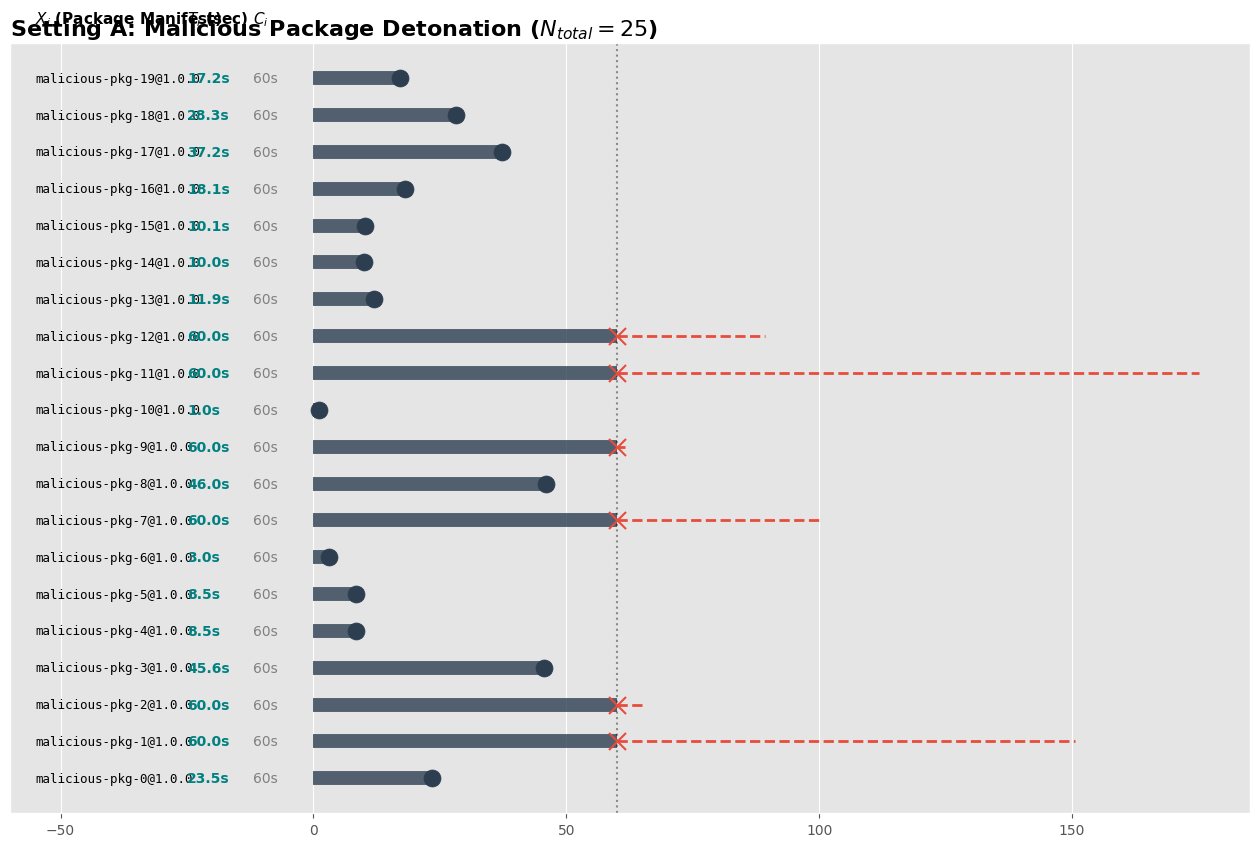

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from matplotlib.lines import Line2D

# --- Configuration ---
plt.style.use('ggplot')

def load_pypi_manifest():
    url = "https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/pypi/manifest.json"
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        df = pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame(data.get('samples', data))
        
        # --- NEW: Print Total Count ---
        print(f"✅ Successfully loaded Malicious Package Dataset.")
        print(f"📊 Total Number of Examples (N): {len(df)}")
        print("-" * 40)
        return df
    except Exception as e:
        print(f"Error fetching manifest: {e}")
        return pd.DataFrame([{"name": f"malicious-pkg-{i}", "version": "1.0.0"} for i in range(25)])

def print_package_xi(df, idx=0):
    row = df.iloc[idx]
    print("="*85)
    print(f"FORMAL REPRESENTATION OF $X_{{{idx}}}$ (Software Artifact)")
    print("="*85)
    print(f"| Package Name:   {row.get('name', 'unknown')}")
    print(f"| Version:        {row.get('version', 'unknown')}")
    print(f"| Static Signals: [Obfuscation Score, Dependency Count, Install-Script Presence]")
    print("-" * 40)

def plot_detonation_survival(df):
    df_subset = df.head(20).copy()
    C_fixed = 60 
    np.random.seed(42)
    Y_simulated = np.random.exponential(scale=50, size=len(df_subset))
    
    fig, ax = plt.subplots(figsize=(16, 10))
    col_x, col_t, col_c = -55, -25, -12
    
    header_y = 20.5
    ax.text(col_x, header_y, "$X_i$ (Package Manifest)", fontweight='bold', fontsize=11)
    ax.text(col_t, header_y, "$T_i$ (sec)", fontweight='bold', fontsize=11)
    ax.text(col_c, header_y, "$C_i$", fontweight='bold', fontsize=11)

    for i in range(len(df_subset)):
        row = df_subset.iloc[i]
        name, version = row.get('name', 'pkg'), row.get('version', 'v1')
        t_obs = min(Y_simulated[i], C_fixed)
        is_censored = Y_simulated[i] > C_fixed
        
        ax.text(col_x, i, f"{name[:25]}@{version}", va='center', fontsize=9, family='monospace')
        ax.text(col_t, i, f"{t_obs:.1f}s", va='center', fontsize=10, color='teal', fontweight='bold')
        ax.text(col_c, i, f"{C_fixed}s", va='center', fontsize=10, color='gray')

        ax.plot([0, t_obs], [i, i], color='#2c3e50', lw=10, solid_capstyle='butt', alpha=0.8)
        if is_censored:
            ax.plot([t_obs, Y_simulated[i]], [i, i], color='#e74c3c', lw=2, ls='--')
            ax.scatter(t_obs, i, color='#e74c3c', marker='x', s=150, zorder=5)
        else:
            ax.scatter(t_obs, i, color='#2c3e50', marker='o', s=150, zorder=5)

    ax.axvline(C_fixed, color='black', linestyle=':', alpha=0.4)
    ax.set_title("Setting A: Malicious Package Detonation ($N_{total}=" + str(len(df)) + "$)", loc='left', fontsize=16, fontweight='bold')
    ax.set_xlim(-60, max(Y_simulated) + 10)
    ax.set_yticks([])
    plt.show()

if __name__ == "__main__":
    pypi_df = load_pypi_manifest()
    print_package_xi(pypi_df, idx=5)
    plot_detonation_survival(pypi_df)